In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [5]:
users_df = pd.read_csv("../data/users.csv")
events_df = pd.read_csv("../data/events_base.csv")
resources_df = pd.read_csv("../data/resources.csv")
sessions_df = pd.read_csv("../data/sessions.csv")

### Merging all 4 files into a single df

In [6]:
df = sessions_df.merge(events_df, on=["session_id", 'user_id'], how = 'left')
df = df.merge(users_df, on =['user_id'], how = 'left')
df = df.merge(resources_df, on = ['resource_id'], how = 'left')

### Aggregating sessions by session_id

In [7]:
df["cross_department_access"] = (
    df["department"] != df["owner_department"]
).astype(int)

In [8]:
df["sensitive_access"] = (
    (df["sensitivity_score"] >= 0.6) & (df["sensitivity_score"] < 0.9)
).astype(int)

In [9]:
df['admin_only_access'] = (
    df['sensitivity_score'] >= 0.9
).astype(int)

In [10]:
df["admin_misuse"] = (
    (df["resource_type"] == "admin_only") &
    (df["privilege_level"] < 3)
).astype(int)

In [11]:
df["invalid_access"] = (
    df["access_success"] == False
).astype(int)

In [12]:
grouped_df = df.groupby("session_id").agg({
    "event_id": "count",
    "data_volume_mb": "sum",
    "invalid_access": "sum",
    "cross_department_access": "sum",
    "sensitive_access": "sum",
    "admin_only_access": "sum",
    "admin_misuse": "sum",
    "resource_id": "nunique",
    "sensitivity_score": "mean"
}).reset_index()

In [13]:
grouped_df = grouped_df.rename(columns={
    "event_id": "total_events",
    "data_volume_mb": "total_data_volume",
    "invalid_access": "failed_attempts",
    "cross_department_access": "cross_dept_count",
    "sensitive_access": "sensitive_resource_count",
    "admin_only_access": "admin_only_resource_count",
    "admin_misuse": "admin_misuse_count",
    "resource_id": "unique_resources",
    "sensitivity_score": "avg_sensitivity"
})

In [14]:
grouped_df = grouped_df.merge(
    sessions_df,
    on=["session_id"],
    how="left"
)

In [15]:
grouped_df = grouped_df.merge(
    users_df[[
        "user_id",
        "tenure_months",
        "role",
        "privilege_level",
        "typical_login_hour",
        "login_hour_std"
    ]],
    on="user_id",
    how="left"
)

### Adding event types and session duration

In [16]:
grouped_df["session_duration"] = (
    pd.to_datetime(grouped_df["session_end"]) -
    pd.to_datetime(grouped_df["session_start"])
).dt.total_seconds() / 60

In [17]:
event_type_counts = pd.crosstab(df["session_id"], df["event_type"])

In [18]:
grouped_df = grouped_df.merge(
    event_type_counts,
    on="session_id",
    how="left"
)

### Calculating the login hour deviation

In [19]:
grouped_df["login_hour"] = pd.to_datetime(
    grouped_df["session_start"]
).dt.hour

In [20]:
grouped_df["login_zscore"] = (
    grouped_df["login_hour"] - grouped_df["typical_login_hour"]
) / grouped_df["login_hour_std"]

grouped_df["abs_login_z"] = abs(grouped_df["login_zscore"])

### Dropping redudant columns which are unique and date times

In [21]:
grouped_df = grouped_df.drop(columns=["session_start", "session_end"])

### Storing event ratios instead of raw counts

In [22]:
grouped_df["failed_ratio"] = (
    grouped_df["failed_attempts"] / grouped_df["total_events"]
)

In [23]:
grouped_df["admin_ratio"] = (
    grouped_df["admin_action"] / grouped_df["total_events"]
)

In [24]:
grouped_df["sensitive_ratio"] = (
    grouped_df["sensitive_resource_count"] / grouped_df["total_events"]
)

In [25]:
grouped_df["admin_only_ratio"] = (
    grouped_df["admin_only_resource_count"] / grouped_df["total_events"]
)

In [26]:
grouped_df["cross_dept_ratio"] = (
    grouped_df["cross_dept_count"] / grouped_df["total_events"]
)

In [27]:
grouped_df["resource_density"] = (
    grouped_df["unique_resources"] / grouped_df["total_events"]
)

In [28]:
grouped_df["api_ratio"] = (
    grouped_df["api_call"] / grouped_df["total_events"]
)

In [29]:
grouped_df["file_ratio"] = (
    grouped_df["file_access"] / grouped_df["total_events"]
)

In [30]:
grouped_df["events_per_minute"] = (
    grouped_df["total_events"] /
    grouped_df["session_duration"]
)

In [31]:
grouped_df["avg_data_per_event"] = (
    grouped_df["total_data_volume"] / grouped_df["total_events"]
)

In [32]:
grouped_df = grouped_df.drop(columns=["cross_dept_count", "sensitive_resource_count","admin_only_resource_count", "admin_action", 'failed_attempts'])

### Dropping columns whose insights have been feature engineered

In [33]:
grouped_df = grouped_df.drop(columns=["typical_login_hour", "login_hour_std", "api_call", "file_access", "admin_misuse_count", "unique_resources","login_zscore"])

In [34]:
grouped_df.head()

,session_id,total_events,total_data_volume,avg_sensitivity,user_id,device_type,location,login_method,mfa_used,tenure_months,role,privilege_level,session_duration,login_hour,abs_login_z,failed_ratio,admin_ratio,sensitive_ratio,admin_only_ratio,cross_dept_ratio,resource_density,api_ratio,file_ratio,events_per_minute,avg_data_per_event
0,S00001,11,252,0.182727,U000,laptop,India,password,True,17,user,1,112.0,9,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.545455,0.181818,0.818182,0.098214,22.909091
1,S00002,5,29,0.174000,U000,vpn,India,password,False,17,user,1,53.0,8,0.740741,0.200000,0.0,0.000000,0.0,0.000000,0.800000,0.000000,1.000000,0.094340,5.800000
2,S00003,7,42,0.234286,U000,laptop,India,password,False,17,user,1,50.0,8,0.740741,0.142857,0.0,0.142857,0.0,0.000000,1.000000,0.571429,0.428571,0.140000,6.000000
3,S00004,6,77,0.330000,U000,vpn,India,password,True,17,user,1,51.0,11,1.481481,0.000000,0.0,0.333333,0.0,0.000000,0.833333,0.333333,0.666667,0.117647,12.833333
4,S00005,7,63,0.272857,U000,vpn,India,password+token,True,17,user,1,71.0,9,0.000000,0.000000,0.0,0.285714,0.0,0.142857,0.714286,0.428571,0.571429,0.098592,9.000000


In [35]:
grouped_df.select_dtypes(include=['float64', 'int64']).corr()

,total_events,total_data_volume,avg_sensitivity,tenure_months,privilege_level,session_duration,abs_login_z,failed_ratio,admin_ratio,sensitive_ratio,admin_only_ratio,cross_dept_ratio,resource_density,api_ratio,file_ratio,events_per_minute,avg_data_per_event
total_events,1.000000,0.440414,-0.097418,0.158618,0.353255,0.285011,0.099169,-0.179337,0.066076,-0.130737,0.116814,0.044829,-0.455034,-0.015355,0.003592,0.475534,0.031445
total_data_volume,0.440414,1.000000,-0.144492,0.174889,0.251313,0.255815,0.033501,-0.212527,0.072493,-0.181741,0.103109,-0.051583,-0.130016,-0.201202,0.189175,0.093376,0.831602
avg_sensitivity,-0.097418,-0.144492,1.000000,-0.264904,-0.037290,-0.104504,-0.033285,0.489735,0.163066,0.935747,0.173429,0.074901,-0.236265,0.009654,-0.038910,0.036055,-0.140962
tenure_months,0.158618,0.174889,-0.264904,1.000000,0.222412,0.172941,-0.033867,-0.203904,0.078745,-0.317769,0.095876,0.010055,0.137422,-0.081325,0.067607,-0.051834,0.110964
privilege_level,0.353255,0.251313,-0.037290,0.222412,1.000000,0.422398,0.072080,-0.193864,0.380750,-0.183362,0.463584,0.094326,0.009440,-0.005628,-0.062550,-0.068517,0.099694
session_duration,0.285011,0.255815,-0.104504,0.172941,0.422398,1.000000,0.079397,-0.189849,0.151248,-0.154513,0.173983,0.031944,-0.001686,-0.052327,0.025483,-0.599299,0.137755
abs_login_z,0.099169,0.033501,-0.033285,-0.033867,0.072080,0.079397,1.000000,-0.047542,-0.022940,-0.009179,-0.045457,0.034267,0.003057,-0.004968,0.009101,-0.005406,-0.000721
failed_ratio,-0.179337,-0.212527,0.489735,-0.203904,-0.193864,-0.189849,-0.047542,1.000000,-0.080110,0.522226,-0.090894,-0.050409,-0.082677,-0.023283,0.037744,-0.004477,-0.204554
admin_ratio,0.066076,0.072493,0.163066,0.078745,0.380750,0.151248,-0.022940,-0.080110,1.000000,-0.100912,0.903921,0.192080,0.076363,-0.115692,-0.062889,-0.042411,0.035513
sensitive_ratio,-0.130737,-0.181741,0.935747,-0.317769,-0.183362,-0.154513,-0.009179,0.522226,-0.100912,1.000000,-0.122737,0.024935,-0.260197,0.033277,-0.015359,0.043134,-0.164010


## Visualizing Trends in the data and defining normal behaviour

In [36]:
fig = px.histogram(
    grouped_df,
    x="session_duration",
    nbins=40,
    title="Session Duration Distribution",
    hover_data=["session_id", "role"]
)

fig.update_layout(bargap=0.1)
fig.show()

In [37]:
fig = px.histogram(
    grouped_df,
    x="abs_login_z",
    nbins=40,
    title="Login Deviation (Z-Score) Distribution",
    hover_data=["session_id", "role"]
)

fig.show()

In [38]:
fig = px.histogram(
    grouped_df,
    x="failed_ratio",
    nbins=40,
    title="Failed Access Ratio Distribution",
    hover_data=["session_id", "role"]
)

fig.show()

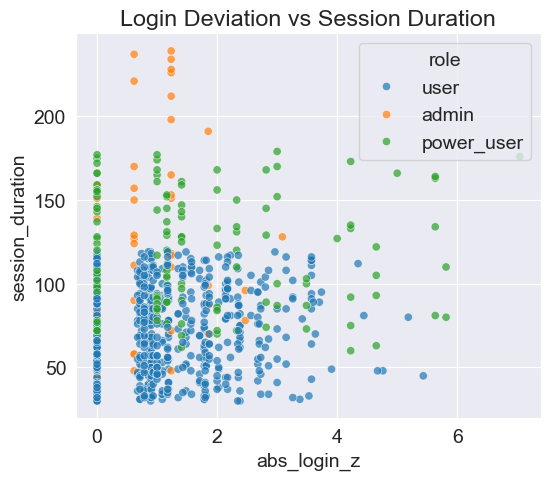

In [39]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=grouped_df,
    x="abs_login_z",
    y="session_duration",
    hue="role",
    alpha=0.7
)
plt.title("Login Deviation vs Session Duration")
plt.show()

In [40]:
fig = px.scatter(
    grouped_df,
    x="abs_login_z",
    y="admin_ratio",
    color="role",
    hover_data=["session_id", "total_events"],
    title="Login Deviation vs Admin Usage"
)

fig.show()

In [41]:
fig = px.scatter(
    grouped_df,
    x="session_duration",
    y="total_data_volume",
    color="role",
    hover_data=["session_id"],
    title="Session Duration vs Data Volume"
)

fig.show()

In [42]:
fig = px.scatter(
    grouped_df,
    x="events_per_minute",
    y="avg_data_per_event",
    color="role",
    hover_data=["session_id"],
    title="Activity Burstiness vs Data Intensity"
)

fig.show()

In [43]:
fig = px.box(
    grouped_df,
    x="privilege_level",
    y="total_events",
    color="privilege_level",
    hover_data=["session_id"],
    title="Activity Level by Privilege Level"
)

fig.show()

In [44]:
corr = grouped_df.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=False,
    color_continuous_scale="RdBu",
    title="Feature Correlation Heatmap"
)

fig.show()

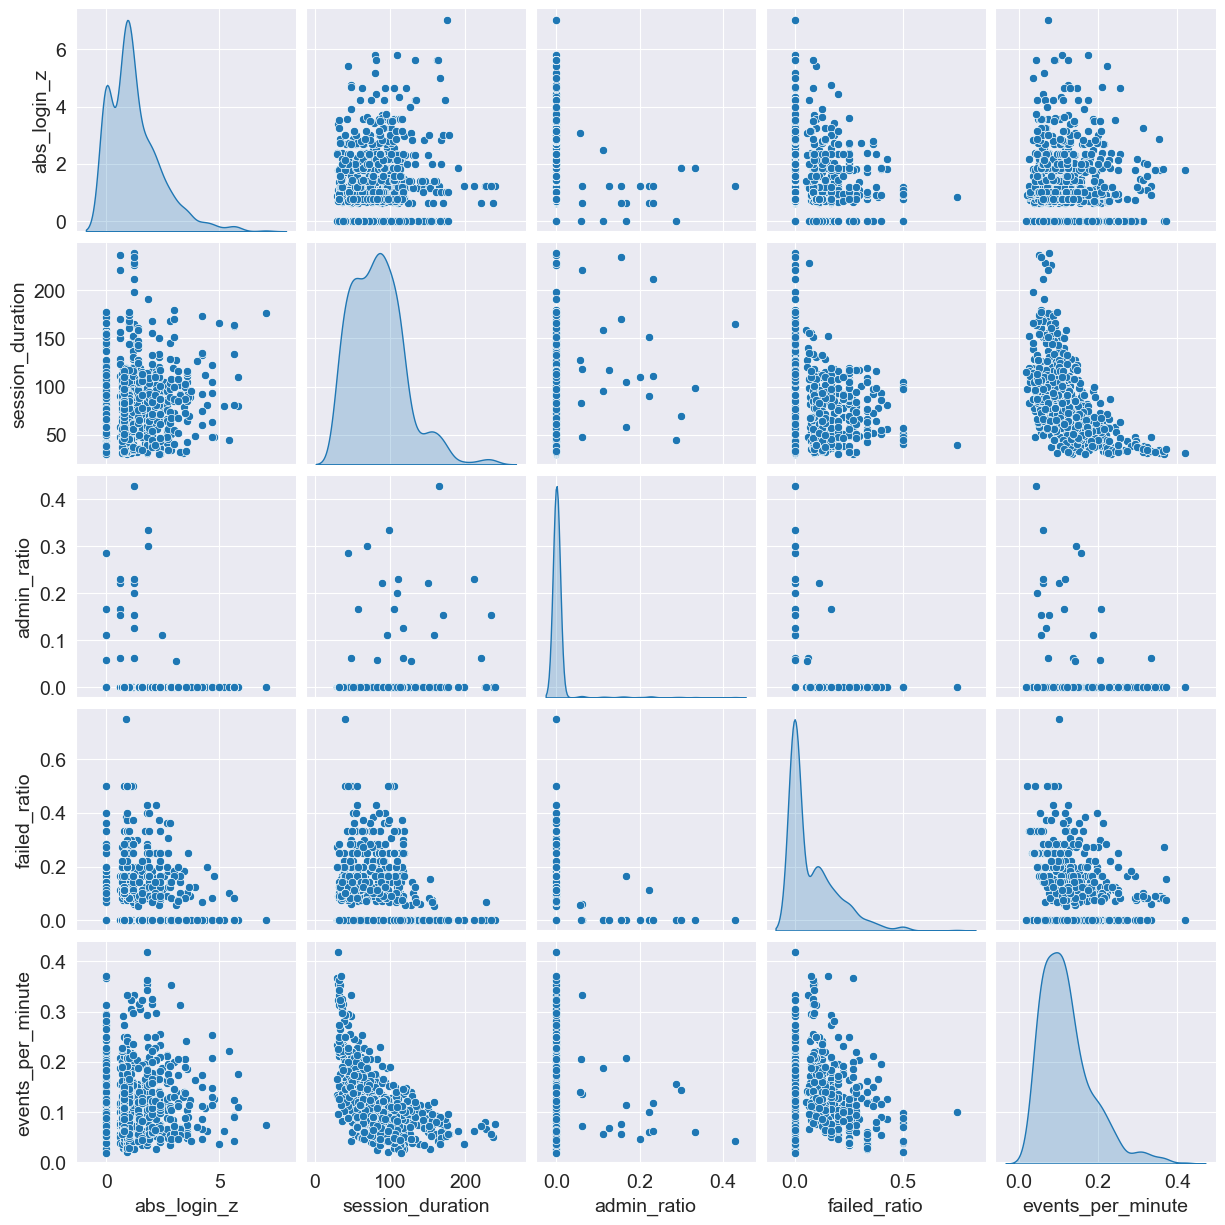

In [45]:
sns.pairplot(
    grouped_df[[
        "abs_login_z",
        "session_duration",
        "admin_ratio",
        "failed_ratio",
        "events_per_minute"
    ]],
    diag_kind="kde"
)
plt.show()

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numeric_df = grouped_df.select_dtypes(include="number")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

grouped_df["PC1"] = X_pca[:,0]
grouped_df["PC2"] = X_pca[:,1]

fig = px.scatter(
    grouped_df,
    x="PC1",
    y="PC2",
    color="role",
    hover_data=[
        "session_id",
        "abs_login_z",
        "admin_ratio",
        "failed_ratio"
    ],
    title="PCA Projection of Sessions"
)

fig.show()